Data loading 

In [1]:
# Import the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sb 


In [2]:
# Load the Topo Chico dataset
df = pd.read_csv("c:/users/kaustubh/onedrive/desktop/cpg-product-intelligence/datasets/fairlife_from_dump.csv")

In [5]:
df

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
0,256312008627,"Fairlife, Purely Nutritious Milk",Fairlife Llc,NaN,united-states,NaN,NaN,NaN,unknown,NaN,unknown,"Reduced fat filtered milk (high protein, high ...",2.50,50.0
1,811620020169,Whole ultra-filtered milk,fairlife,"beverages-and-beverages-preparations, beverage...",united-states,NaN,NaN,NaN,b,1.0,NaN,"ultra-filtered milk, lactase enzyme, vitamin a...",NaN,NaN
2,811620020398,Chocolate Reduced Fat Ultra-Filtered Milk,fairlife,"beverages-and-beverages-preparations, beverage...",united-states,NaN,NaN,NaN,d,4.0,NaN,"Low fat ultra-filtered milk, sugar, alkalized ...",NaN,NaN
3,811620020404,STRAWBERRY 2% REDUCED FAT ultra-filtered milk,fairlife,"beverages-and-beverages-preparations, beverage...",united-states,NaN,NaN,NaN,d,4.0,NaN,"Low fat ultra-filtered milk, sugar, natural fl...",NaN,NaN
4,811620021012,Rich chocolate nutrition shake with honey & oats,Fairlife Smart Milkshakes,"dairies, milks",united-states,NaN,NaN,NaN,d,4.0,d,"Filtered reduced fat grade a milk, honey, alka...",4.58,71.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,11620022118,Chocolate Nutrition Shake,fairlife,NaN,united-states,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
206,52115783,Core Power Elite Strawberry High Protein Milk ...,fairlife,NaN,united-states,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
207,1162002065,Core Power High Protein Milk Shake Vanilla,fairlife,NaN,united-states,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN
208,884912002427,Vanilla Cream,fairlife,NaN,united-states,NaN,NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN


#Data Cleaning 

In [3]:
# Inspect the data types of all columns to identify any required conversions.
df.dtypes

code                             int64
product_name                       str
brands                             str
categories_tags                    str
countries_tags                     str
packaging_tags                     str
stores                             str
purchase_places                    str
nutriscore_grade                   str
nova_group                     float64
ecoscore_grade                     str
ingredients_text                   str
nutriments.sugars_100g         float64
nutriments.energy-kcal_100g    float64
dtype: object

In [4]:
# Examine the product code values before converting the column to a numeric type.
df.code.unique()

array([ 256312008627,  811620020169,  811620020398,  811620020404,
        811620021012,  856312002207,  856312002634,  856312002757,
        856312002795,  811620020657,  811620021951,  811620021388,
        811620021784,  811620022118,   72060001327,  811620022125,
        811620020879,  811620020626,  811620020893,  811620021418,
        811620022248,      21160202,  811620020671,  811620021791,
        811620021777,  811620020695,  811620022750,  811620022194,
        811620022132,  811620022149, 6764512002757,  811620022514,
       1818676022740,  852455005778,      22154071,  811620022927,
        811620021739,      81161775,  811620002127,  811620061933,
        811620022996,       4757839, 3818970000350,  351652900447,
       3357934020336,   49000550122,   49000550115,  432976785979,
       1817676021982,  811620022187,      96356340,  671620022118,
        600934020305,  801300020633,  811620020367, 3857960020633,
         49000551365,      18636714,  811620024020,  811620022

In [7]:
# Review the unique brand names to identify inconsistent spellings.
df.brands.unique()

<ArrowStringArray>
[                    'Fairlife Llc',                         'fairlife',
        'Fairlife Smart Milkshakes',     'Fair Oaks Farms Brands  Inc.',
                         'Fairlife',                                nan,
 'fairlife nutrition plan,fairlife',             'Fairlife,Minute Maid',
          'fairlife plan nutrition',                        'Fair life',
                      'Core  Power',               'Fueled By Fairlife',
              'Core Power Fairlife',           'Core Power By Fairlife',
          'fairlife nutrition plan']
Length: 15, dtype: str

In [9]:
# Standardize brand names by correcting inconsistent spellings and capitalization.
# This ensures all variations of the same brand are grouped together.
df.brands = df.brands.replace({
    "Fairlife Llc" : "Fairlife",
    "fairlife" : "Fairlife",
    "Fairlife Smart Milkshakes" : "Fairlife",
    "Fair Oaks Farms Brands  Inc." : "Fairlife",
    " nan" : "Fairlife",
    "fairlife nutrition plan,fairlife" : "Fairlife",
    "Fairlife,Minute Maid" : "Fairlife",
    "fairlife plan nutrition" : "Fairlife",
    "Fair life" : "Fairlife",
    "Core Power Fairlife" : "Fairlife",
    "Core Power By Fairlife" : "Fairlife",
    "fairlife nutrition plan" : "Fairlife"}, regex=True)

In [8]:
# Replace missing brand values with 'Unknown' to avoid null values.
df.brands = df.brands.fillna("unknown")
df.brands.isnull().sum()

np.int64(0)

In [10]:
# Replace missing values in selected categorical columns with 'Unknown'.
cols = [
    "categories_tags",
    "countries_tags",
    "packaging_tags",
    "stores",
    "purchase_places",
    "ecoscore_grade",
    "ingredients_text"
    
    
]

df[cols] = df[cols].fillna("Unknown")

#Data Preparation

In [11]:
# Create a cleaned copy of the dataset.
# All subsequent preprocessing steps are performed on this copy to preserve the original data.
df_clean = df.copy()

In [12]:
# Split multiple country tags into individual rows and standardize
# the text by trimming spaces and converting to lowercase.
country_df = df_clean.copy()
country_df["countries_tags"] = country_df["countries_tags"].str.split(",")
country_df = country_df.explode("countries_tags")
country_df["countries_tags"] = country_df["countries_tags"].str.strip().str.lower()

In [13]:
# Split multiple packaging tags into separate rows and standardize
# the values for accurate packaging analysis.
pack_df = df_clean.copy()
pack_df["packaging_tags"] = pack_df["packaging_tags"].str.split(",")
pack_df = pack_df.explode("packaging_tags")
pack_df["packaging_tags"] = pack_df["packaging_tags"].str.strip().str.lower()

In [14]:
# Split multiple category tags into separate rows and standardize
# the text for consistent category analysis.
cat_df = df_clean.copy()
cat_df["categories_tags"] = cat_df["categories_tags"].str.split(",")
cat_df = cat_df.explode("categories_tags")
cat_df["categories_tags"] = cat_df["categories_tags"].str.strip().str.lower()

In [15]:
# Split multiple store names into individual rows and standardize
# the values for store-level analysis.
store_df = df_clean.copy()
store_df["stores"] = store_df["stores"].str.split(",")
store_df = store_df.explode("stores")
store_df["stores"] = store_df["stores"].str.strip().str.lower()

In [16]:
# Display the frequency of each brand.
df.brands.value_counts()

brands
Fairlife                            184
unknown                              19
Fairlife nutrition plan,Fairlife      2
Fairlife nutrition plan               2
Fairlife plan nutrition               1
Core  Power                           1
Fueled By Fairlife                    1
Name: count, dtype: int64

In [17]:
# Display the number of products available in each country.
country_df.value_counts("countries_tags")

countries_tags
united-states         128
canada                 39
italy                  19
ireland                10
unknown                 3
france                  2
germany                 2
thailand                2
australia               2
south-africa            1
croatia                 1
finland                 1
dominican-republic      1
spain                   1
Name: count, dtype: int64

In [18]:
# Display the frequency of each packaging type.
pack_df.value_counts("packaging_tags")

packaging_tags
unknown                           202
plastic                             7
bottle                              5
pet-polyethylene-terephthalate      1
bottle-or-vial                      1
Name: count, dtype: int64

In [19]:
# Display the frequency of each product category.
cat_df.value_counts("categories_tags")

categories_tags
unknown                                 164
dairies                                  29
dietary-supplements                      24
beverages                                21
bodybuilding-supplements                 21
milks                                    20
protein-shakes                           20
dairy-drinks                             18
beverages-and-beverages-preparations     17
milks-liquid-and-powder                  13
flavoured-milks                          13
chocolate-milks                           7
milkshakes                                5
lactose-free-milk                         2
protein-drink                             2
whole-milks                               1
strawberry-milks                          1
skimmed-milks                             1
protein                                   1
chocolate reduced milk                    1
plastic bottle                            1
semi-skimmed-milks                        1
cow-milks       

In [20]:
# Display the frequency of products available across stores.
store_df.value_counts("stores")

stores
unknown                     207
metro                         2
real canadian superstore      1
urban fare                    1
Name: count, dtype: int64

In [ ]:
# Calculate the total number of unique brands.
print("Total Brands :", df["brands"].nunique())

Total Brands : 7


In [ ]:
# Calculate the total number of unique categories.
print("Total Categories :", cat_df["categories_tags"].nunique())

Total Categories : 32


In [24]:
# Calculate the total number of nunique categories.
print("Total Countries :", country_df["countries_tags"].nunique())

Total Countries : 14


In [25]:
# Calculate the total number of unique packaging types.
print("Total Packaging Types :", pack_df["packaging_tags"].nunique())

Total Packaging Types : 5


In [26]:
# Calculate the total number of unique stores.
print("Total Stores :", store_df["stores"].nunique())

Total Stores : 4


Dataset Summary

In [27]:
# Convert all non-numeric columns to object type to ensure
df[df.select_dtypes(exclude='number').columns] = df.select_dtypes(exclude='number').astype(object)

In [28]:
# Create a summary table showing the number of unique values,
# missing values, and data type for each column.
# This provides an overview of the dataset after preprocessing.
summary = pd.DataFrame({
    "Unique Values": df.nunique(),
    "Missing Values": df.isnull().sum(),
    "Data Type": df.dtypes
})

summary

,Unique Values,Missing Values,Data Type
code,210,0,int64
product_name,162,0,object
brands,7,0,object
categories_tags,31,0,object
countries_tags,16,0,object
packaging_tags,6,0,object
stores,4,0,object
purchase_places,3,0,object
nutriscore_grade,7,0,object
nova_group,3,157,float64


Analyze one at a time

Brands

In [31]:
print(df["brands"].describe())

df["brands"].value_counts()

count          191
unique           6
top       Fairlife
freq           184
Name: brands, dtype: object


brands
Fairlife                            184
Fairlife nutrition plan,Fairlife      2
Fairlife nutrition plan               2
Fairlife plan nutrition               1
Core  Power                           1
Fueled By Fairlife                    1
Name: count, dtype: int64

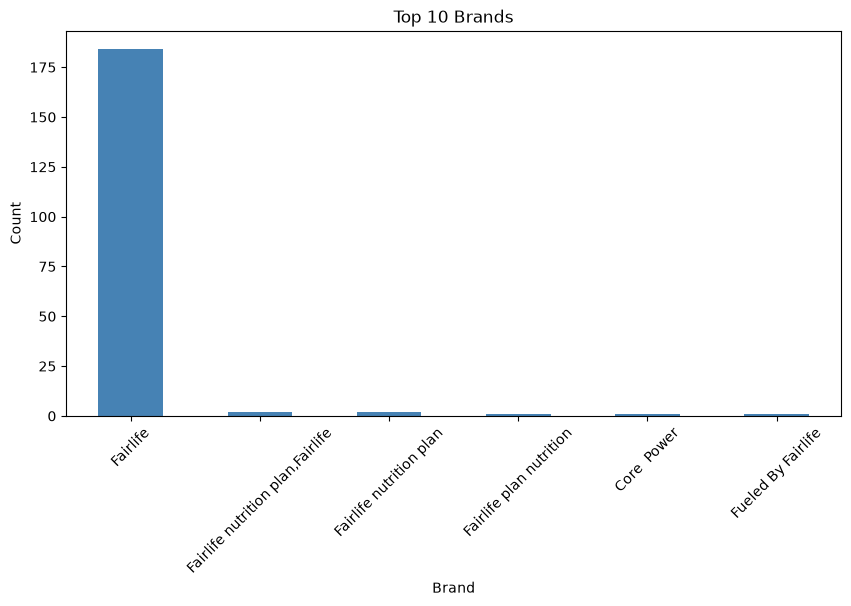

In [32]:
plt.figure(figsize=(10,5))

df["brands"].value_counts().head(10).plot(
    kind="bar",
    color="steelblue"
)

plt.title("Top 10 Brands")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

Categories

In [33]:
cat_df["categories_tags"].value_counts().head(15)

categories_tags
unknown                                 164
dairies                                  29
dietary-supplements                      24
beverages                                21
bodybuilding-supplements                 21
milks                                    20
protein-shakes                           20
dairy-drinks                             18
beverages-and-beverages-preparations     17
milks-liquid-and-powder                  13
flavoured-milks                          13
chocolate-milks                           7
milkshakes                                5
lactose-free-milk                         2
protein-drink                             2
Name: count, dtype: int64

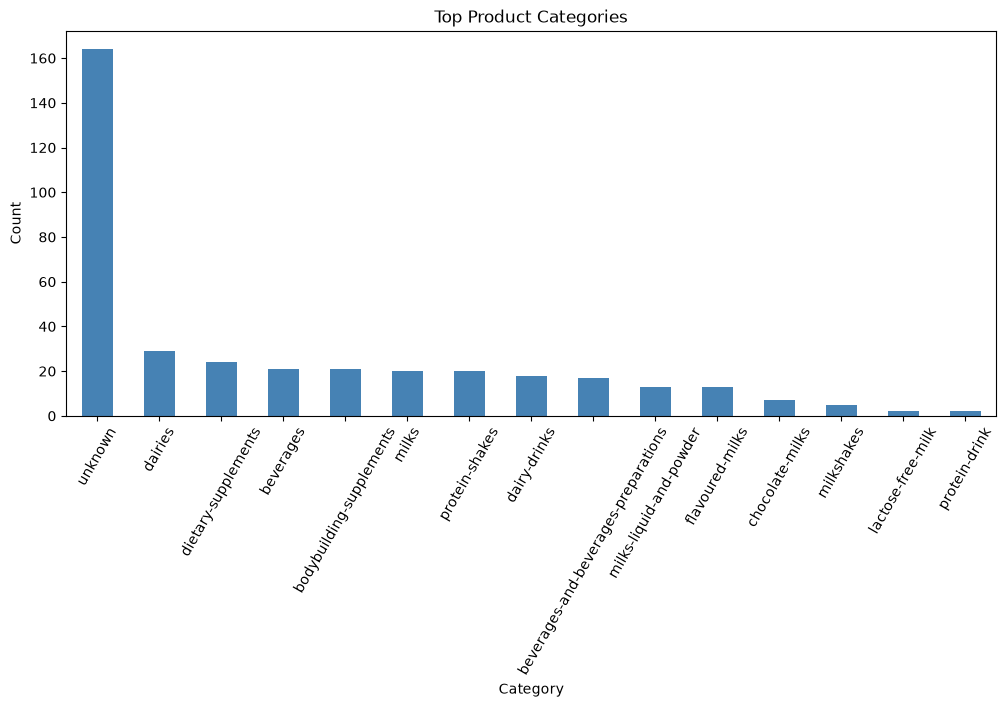

In [29]:
plt.figure(figsize=(12,5))

cat_df["categories_tags"].value_counts().head(15).plot(
    kind="bar",
    color="steelblue"
)

plt.title("Top Product Categories")
plt.xlabel("Category")
plt.ylabel("Count")

plt.xticks(rotation=60)

plt.show()

Countries


In [35]:
country_df["countries_tags"].value_counts().head(15)

countries_tags
united-states         128
canada                 39
italy                  19
ireland                10
unknown                 3
france                  2
germany                 2
thailand                2
australia               2
south-africa            1
croatia                 1
finland                 1
dominican-republic      1
spain                   1
Name: count, dtype: int64

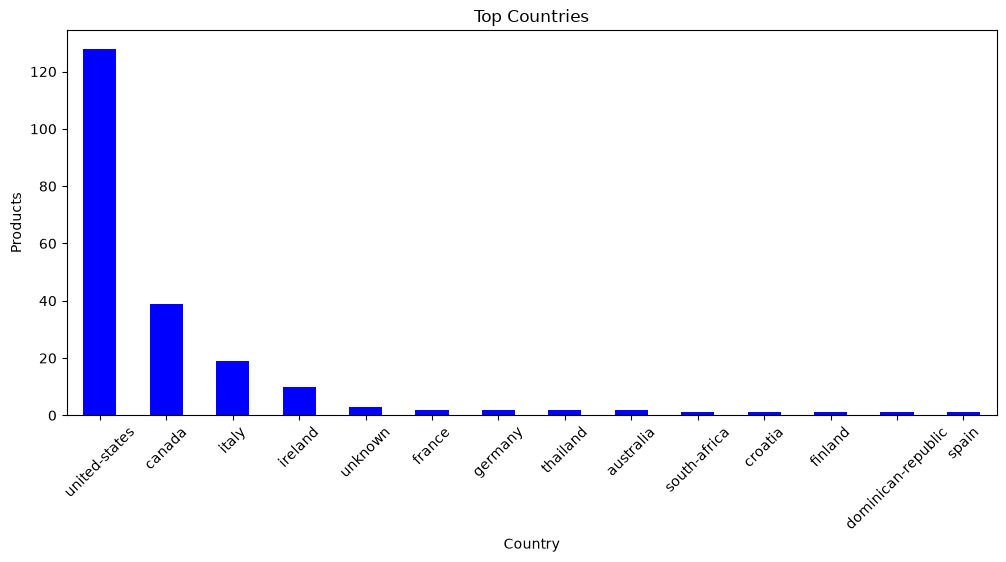

In [37]:
plt.figure(figsize=(12,5))

country_df["countries_tags"].value_counts().plot(
    kind="bar",
    color="blue"
)

plt.title("Top Countries")
plt.xlabel("Country")
plt.ylabel("Products")

plt.xticks(rotation=45)

plt.show()

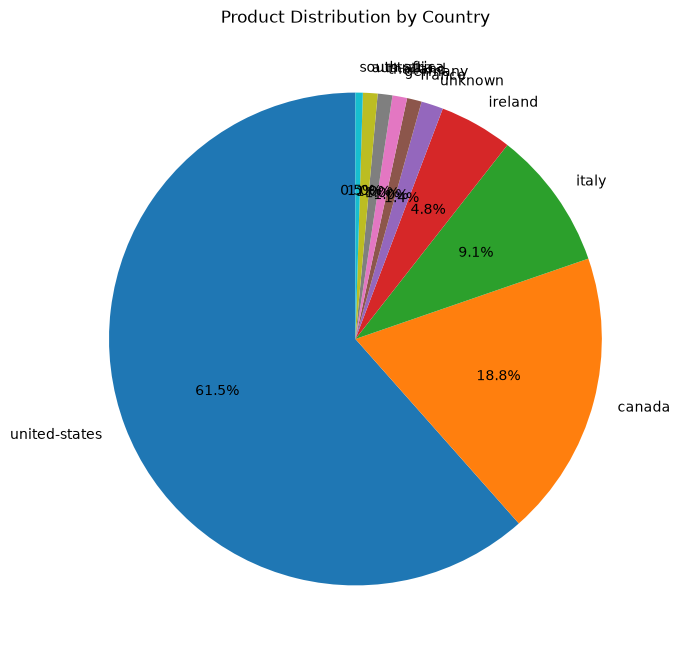

In [38]:
top10 = country_df["countries_tags"].value_counts().head(10)

plt.figure(figsize=(8,8))

plt.pie(
    top10,
    labels=top10.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Product Distribution by Country")

plt.show()

Packaging

In [39]:
pack_df["packaging_tags"].value_counts().head(15)

packaging_tags
unknown                           202
plastic                             7
bottle                              5
pet-polyethylene-terephthalate      1
bottle-or-vial                      1
Name: count, dtype: int64

Stores

In [40]:
store_df["stores"].value_counts().head(15)

stores
unknown                     207
metro                         2
real canadian superstore      1
urban fare                    1
Name: count, dtype: int64

purchase place


In [41]:
df["purchase_places"].value_counts().head(15)

purchase_places
Unknown                   207
Calgary,Alberta,Canada      2
Canada                      1
Name: count, dtype: int64

Eco score

In [42]:
df["ecoscore_grade"].value_counts()

ecoscore_grade
Unknown    163
unknown     43
d            4
Name: count, dtype: int64

In [43]:
# Create country-level dataframe
country_df = df.copy()

# Split multiple countries
country_df["countries_tags"] = (
    country_df["countries_tags"]
    .fillna("")
    .str.split(",")
)

country_df = country_df.explode("countries_tags")

# Clean country names
country_df["countries_tags"] = (
    country_df["countries_tags"]
    .str.strip()
    .str.lower()
)

# Remove empty countries
country_df = country_df[
    country_df["countries_tags"] != ""
]

country_df.head()

,code,product_name,brands,categories_tags,countries_tags,packaging_tags,stores,purchase_places,nutriscore_grade,nova_group,ecoscore_grade,ingredients_text,nutriments.sugars_100g,nutriments.energy-kcal_100g
0,256312008627,"Fairlife, Purely Nutritious Milk",Fairlife,Unknown,united-states,Unknown,Unknown,Unknown,unknown,NaN,unknown,"Reduced fat filtered milk (high protein, high ...",2.50,50.0
1,811620020169,Whole ultra-filtered milk,Fairlife,"beverages-and-beverages-preparations, beverage...",united-states,Unknown,Unknown,Unknown,b,1.0,Unknown,"ultra-filtered milk, lactase enzyme, vitamin a...",NaN,NaN
2,811620020398,Chocolate Reduced Fat Ultra-Filtered Milk,Fairlife,"beverages-and-beverages-preparations, beverage...",united-states,Unknown,Unknown,Unknown,d,4.0,Unknown,"Low fat ultra-filtered milk, sugar, alkalized ...",NaN,NaN
3,811620020404,STRAWBERRY 2% REDUCED FAT ultra-filtered milk,Fairlife,"beverages-and-beverages-preparations, beverage...",united-states,Unknown,Unknown,Unknown,d,4.0,Unknown,"Low fat ultra-filtered milk, sugar, natural fl...",NaN,NaN
4,811620021012,Rich chocolate nutrition shake with honey & oats,Fairlife,"dairies, milks",united-states,Unknown,Unknown,Unknown,d,4.0,d,"Filtered reduced fat grade a milk, honey, alka...",4.58,71.0


country wise product count


In [44]:
country_product_count = (
    country_df.groupby("countries_tags")["code"]
    .nunique()
    .sort_values(ascending=False)
)

country_product_count.head(20)

countries_tags
united-states         128
canada                 39
italy                  19
ireland                10
unknown                 3
australia               2
thailand                2
germany                 2
france                  2
croatia                 1
finland                 1
dominican-republic      1
south-africa            1
spain                   1
Name: code, dtype: int64

country-wise average calories &sugar 

In [45]:
country_nutrition = (
    country_df.groupby("countries_tags")
    .agg(
        Products=("code", "nunique"),
        Avg_Calories=("nutriments.energy-kcal_100g", "mean"),
        Avg_Sugar=("nutriments.sugars_100g", "mean")
    )
    .reset_index()
)

country_nutrition = country_nutrition.sort_values(
    "Products",
    ascending=False
)

country_nutrition.head(20)

,countries_tags,Products,Avg_Calories,Avg_Sugar
12,united-states,128,56.506963,2.592067
1,canada,39,NaN,NaN
8,italy,19,NaN,NaN
7,ireland,10,NaN,NaN
13,unknown,3,NaN,NaN
0,australia,2,190.000000,8.000000
11,thailand,2,60.000000,4.800000
6,germany,2,NaN,NaN
5,france,2,NaN,NaN
2,croatia,1,55.555556,NaN


Nutrition-score distribtion by country 

In [47]:
# Reset index
country_df = country_df.reset_index(drop=True)

# Remove missing nutrition grades
nutrition_data = country_df.dropna(
    subset=["nutriscore_grade"]
).copy()

# Remove empty country names
nutrition_data = nutrition_data[
    nutrition_data["countries_tags"].notna() &
    (nutrition_data["countries_tags"] != "")
]

# Country-wise Nutrition Score distribution
nutrition_by_country = pd.crosstab(
    nutrition_data["countries_tags"],
    nutrition_data["nutriscore_grade"]
)

nutrition_by_country

nutriscore_grade,a,b,c,d,e,not-applicable,unknown
countries_tags,,,,,,,
australia,0,0,0,0,0,0,2
canada,0,3,0,1,0,8,27
croatia,0,0,0,0,0,0,1
dominican-republic,0,0,0,0,0,0,1
finland,0,0,0,0,0,0,1
france,0,0,0,0,0,0,2
germany,0,0,0,0,0,0,2
ireland,0,0,0,0,0,0,10
italy,0,0,0,0,0,2,17


Percentage of each nutrition grade

In [49]:
nutrition_percentage = pd.crosstab(
    nutrition_data["countries_tags"],
    nutrition_data["nutriscore_grade"],
    normalize="index"
) * 100

nutrition_percentage = nutrition_percentage.round(2)

nutrition_percentage.head(20)

nutriscore_grade,a,b,c,d,e,not-applicable,unknown
countries_tags,,,,,,,
australia,0.00,0.00,0.00,0.00,0.00,0.00,100.00
canada,0.00,7.69,0.00,2.56,0.00,20.51,69.23
croatia,0.00,0.00,0.00,0.00,0.00,0.00,100.00
dominican-republic,0.00,0.00,0.00,0.00,0.00,0.00,100.00
finland,0.00,0.00,0.00,0.00,0.00,0.00,100.00
france,0.00,0.00,0.00,0.00,0.00,0.00,100.00
germany,0.00,0.00,0.00,0.00,0.00,0.00,100.00
ireland,0.00,0.00,0.00,0.00,0.00,0.00,100.00
italy,0.00,0.00,0.00,0.00,0.00,10.53,89.47


Average sugar by country 

In [51]:
sugar_by_country = (
    country_df.groupby("countries_tags")
    ["nutriments.sugars_100g"]
    .mean()
    .sort_values(ascending=False)
)

sugar_by_country.head(20)

countries_tags
australia             8.000000
south-africa          7.000000
thailand              4.800000
united-states         2.592067
finland               0.588235
canada                     NaN
croatia                    NaN
dominican-republic         NaN
france                     NaN
germany                    NaN
ireland                    NaN
italy                      NaN
spain                      NaN
unknown                    NaN
Name: nutriments.sugars_100g, dtype: float64

Average calories by country 

In [52]:
calories_by_country = (
    country_df.groupby("countries_tags")
    ["nutriments.energy-kcal_100g"]
    .mean()
    .sort_values(ascending=False)
)

calories_by_country.head(20)

countries_tags
south-africa          230.000000
australia             190.000000
dominican-republic    140.000000
thailand               60.000000
united-states          56.506963
croatia                55.555556
finland                44.117647
canada                       NaN
france                       NaN
germany                      NaN
ireland                      NaN
italy                        NaN
spain                        NaN
unknown                      NaN
Name: nutriments.energy-kcal_100g, dtype: float64

EcoScore analysis

In [53]:
eco_by_country = pd.crosstab(
    country_df["countries_tags"],
    country_df["ecoscore_grade"],
    normalize="index"
) * 100

eco_by_country.round(2).head(20)

ecoscore_grade,Unknown,d,unknown
countries_tags,,,
australia,0.00,0.00,100.00
canada,100.00,0.00,0.00
croatia,0.00,100.00,0.00
dominican-republic,0.00,0.00,100.00
finland,0.00,0.00,100.00
france,100.00,0.00,0.00
germany,100.00,0.00,0.00
ireland,100.00,0.00,0.00
italy,100.00,0.00,0.00


Nova Processsing level 

In [55]:
nova_by_country = pd.crosstab(
    country_df["countries_tags"],
    country_df["nova_group"],
    normalize="index"
) * 100

nova_by_country.round(2).head(20)

nova_group,1.0,3.0,4.0
countries_tags,,,
canada,23.08,0.00,76.92
italy,0.00,0.00,100.00
united-states,8.11,2.70,89.19
unknown,0.00,33.33,66.67


In [56]:
def analyze_country(country):

    data = country_df[
        country_df["countries_tags"] == country.lower()
    ]

    print(f"COUNTRY: {country.upper()}")
    print("=" * 50)

    print(f"Products: {data['code'].nunique()}")

    print(
        f"Average Calories: "
        f"{data['nutriments.energy-kcal_100g'].mean():.2f} kcal/100g"
    )

    print(
        f"Average Sugar: "
        f"{data['nutriments.sugars_100g'].mean():.2f} g/100g"
    )

    print("\nNutrition Score Distribution:")
    print(
        data["nutriscore_grade"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    print("\nNOVA Distribution:")
    print(
        data["nova_group"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

    print("\nEcoScore Distribution:")
    print(
        data["ecoscore_grade"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

In [58]:
analyze_country("united states")

COUNTRY: UNITED STATES
Products: 0
Average Calories: nan kcal/100g
Average Sugar: nan g/100g

Nutrition Score Distribution:
Series([], Name: proportion, dtype: float64)

NOVA Distribution:
Series([], Name: proportion, dtype: float64)

EcoScore Distribution:
Series([], Name: proportion, dtype: float64)
